<a href="https://colab.research.google.com/github/Abidullha/ReX-GNN/blob/main/ReX_GNN_Setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("✅ NumPy version:", np.__version__)
print("✅ Pandas version:", pd.__version__)
print("✅ Matplotlib version:", plt.__version__ if hasattr(plt, '__version__') else "OK")



✅ NumPy version: 2.0.2
✅ Pandas version: 2.2.2
✅ Matplotlib version: OK


In [4]:
import torch
print("✅ PyTorch version:", torch.__version__)
print("✅ GPU available:", torch.cuda.is_available())


✅ PyTorch version: 2.6.0+cu124
✅ GPU available: True


In [5]:
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.1.0+cu121.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.1.0+cu121.html
!pip install torch-geometric

Looking in links: https://data.pyg.org/whl/torch-2.1.0+cu121.html
Looking in links: https://data.pyg.org/whl/torch-2.1.0+cu121.html


In [8]:
import torch
from torch_geometric.data import Data

# 4 nodes (intersections), each with 2 features: speed, volume
x = torch.tensor([
    [60, 100],   # Node 0
    [45, 130],   # Node 1
    [50, 120],   # Node 2
    [70, 80]     # Node 3
], dtype=torch.float)

# Define edge connections (from → to)
edge_index = torch.tensor([
    [0, 1, 2, 3, 0],  # from
    [1, 2, 3, 0, 2]   # to
], dtype=torch.long)

# Optional: edge weights (like distance, congestion)
edge_attr = torch.tensor([
    [1.0],  # 0 → 1
    [0.5],  # 1 → 2
    [1.2],  # 2 → 3
    [0.7],  # 3 → 0
    [0.9],  # 0 → 2
], dtype=torch.float)

# Create PyG graph object
graph = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

print(graph)


Data(x=[4, 2], edge_index=[2, 5], edge_attr=[5, 1])


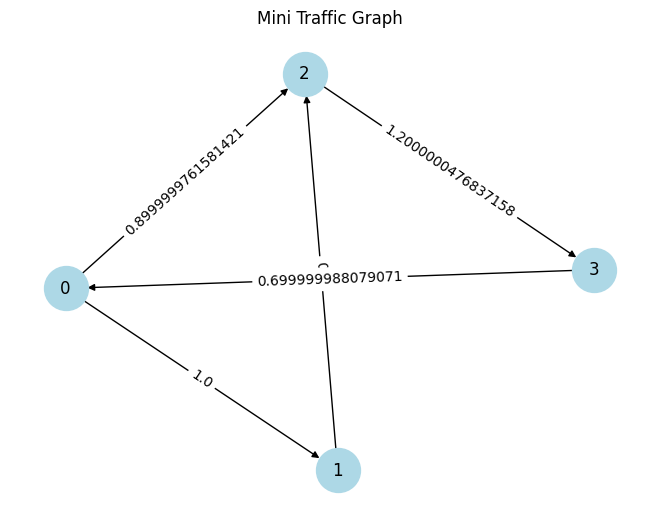

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
edges = edge_index.t().tolist()

for i, (src, dst) in enumerate(edges):
    G.add_edge(src, dst, weight=edge_attr[i].item())

pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=1000, arrows=True)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title("Mini Traffic Graph")
plt.show()


- Graph created with 4 nodes and edge weights
- Learned how PyG uses edge_index and x for features
- Ready to move to full GNN module